<a href="https://colab.research.google.com/github/vitorfs300504/Aula-04/blob/main/laboratorio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import	pandas	as	dp

url	=	"https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df	=	pd.read_csv(url)

#	tratar	valores	ausentes	de	Age	com	a	mediana
df["Age"]	=	df["Age"].fillna(df["Age"].median())

#	codificar	Sex	como	número	(0	=	masculino,	1	=	feminino)
df["Sex"]	=	df["Sex"].map({"male":	0,	"female":	1})

#	conferir	se	ainda	há	valores	ausentes	nas	colunas	que	vamos	usar
print(df[["Pclass",	"Sex",	"Age",	"Fare",	"Survived"]].isnull().sum())

Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
dtype: int64


In [32]:
from	sklearn.model_selection	import	train_test_split
from	sklearn.linear_model	import	LogisticRegression

X	=	df[["Pclass",	"Sex",	"Age",	"Fare"]]
y	=	df["Survived"]

X_train,	X_test,	y_train,	y_test	=	train_test_split(
    X,	y,	test_size=0.2,	random_state=42
)

modelo	=	LogisticRegression(max_iter=1000)
modelo.fit(X_train,	y_train)

print("Modelo	treinado	com",	len(X_train),	"passageiros	de	treino.")

Modelo	treinado	com 712 passageiros	de	treino.


In [33]:
y_pred	=	modelo.predict(X_test)
probs	=	modelo.predict_proba(X_test)

resultado	=	pd.DataFrame({
    "Real":	y_test.values,
    "Previsto":	y_pred,
    "Prob_Sobreviver":	probs[:,	1].round(2)
})

print(resultado.head(10))

   Real  Previsto  Prob_Sobreviver
0     1         0             0.10
1     0         0             0.22
2     0         0             0.12
3     1         1             0.87
4     1         1             0.65
5     1         1             0.92
6     1         1             0.57
7     0         0             0.13
8     1         1             0.64
9     1         1             0.93


In [34]:
passageiro	=	pd.DataFrame({
    "Pclass":	[3],			#	experimente	1,	2	ou	3
    "Sex":	[0],						#	0	=	masculino,	1	=	feminino
    "Age":	[25],
    "Fare":	[15]
})

prob	=	modelo.predict_proba(passageiro)[0][1]
z	=	modelo.decision_function(passageiro)[0]		#	a	"pontuação	bruta"	antes	da	sigmoide

print(f"Pontuação	linear	(z):	{z:.2f}")
print(f"Probabilidade	prevista	de	sobreviver:	{prob:.1%}")

Pontuação	linear	(z):	-2.10
Probabilidade	prevista	de	sobreviver:	10.9%


ValueError: x and y must be the same size

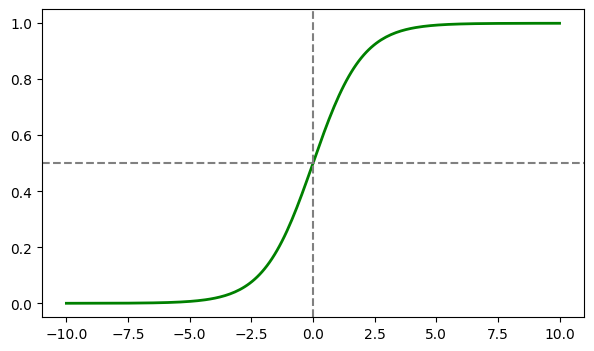

In [35]:
import	numpy	as	np
import	matplotlib.pyplot	as	plt

z	=	np.linspace(-10,	10,	200)
sigmoide	=	1	/	(1	+	np.exp(-z))

plt.figure(figsize=(7,	4))
plt.plot(z,	sigmoide,	color="green",	linewidth=2)
plt.axhline(0.5,	color="gray",	linestyle="--")
plt.axvline(0,	color="gray",	linestyle="--")
plt.scatter([z],	[prob],	color="red",	zorder=5,	s=80)
plt.title("Função	Sigmoide	—	seu	passageiro	em	destaque")
plt.xlabel("z	(pontuação	linear)")
plt.ylabel("Probabilidade	prevista")
plt.show()